<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>01 → Logistic Regression on Breast Cancer Dataset</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Binary Classification, Sigmoid Function, Feature Standardization, Odds Ratios, ROC-AUC & Decision Threshold Tuning)</span>
</div>


---

# Table of Contents 

1. [Task 1: Mathematical Foundations: Sigmoid, Log-Odds & Cross-Entropy Loss](#1-mathematical-foundations)
2. [Task 2: Visualizing the Sigmoid Activation Function & Logit Space](#2-visualizing-sigmoid)
3. [Task 3: Import Libraries & Ingest Wisconsin Breast Cancer Dataset](#3-import-libraries-data)
4. [Task 4: Exploratory Data Analysis (EDA) & Target Class Balance](#4-eda-target-balance)
5. [Task 5: Multicollinearity & Feature Correlation Analysis](#5-correlation-multicollinearity)
6. [Task 6: Feature Standardization & Stratified Train-Test Split](#6-standardization-split)
7. [Task 7: Baseline Logistic Regression Model & Convergence Analysis](#7-baseline-logistic)
8. [Task 8: Model Interpretability — Feature Coefficients & Odds Ratios (Odds Ratios exp(Beta))](#8-coefficients-odds-ratios)
9. [Task 9: Hyperparameter Optimization: Regularization Paths (L1 Lasso vs L2 Ridge)](#9-regularization-paths)
10. [Task 10: Decision Threshold Optimization & Precision-Recall Trade-off](#10-threshold-tuning)
11. [Task 11: 2D Feature Space Decision Boundary via PCA](#11-pca-decision-boundary)
12. [Task 12: Comprehensive Final Model Evaluation (ROC-AUC, PR-AUC & Calibration)](#12-model-evaluation)
13. [Task 13: Clinical Insights & Practical Guidelines](#13-summary-takeaways)

---


<a id="1-mathematical-foundations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Task 1: Mathematical Foundations: Sigmoid, Log-Odds & Cross-Entropy Loss</span>


**Logistic Regression** is the canonical generalized linear model (GLM) for binary classification. While ordinary linear regression predicts unbounded continuous responses $\hat{y} \in (-\infty, +\infty)$, Logistic Regression squashes linear combinations through a non-linear link function into valid probability estimates $\hat{p} \in (0, 1)$.

### 1. The Sigmoid (Logistic) Function
Given an input vector $\mathbf{x} \in \mathbb{R}^d$ and parameter weights $\mathbf{w} \in \mathbb{R}^d, b \in \mathbb{R}$, define the linear logit score:

$$
z = \mathbf{w}^T \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \dots + w_d x_d + b
$$

The sigmoid activation maps $z$ to a posterior probability:

$$
P(y = 1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}} = \frac{e^z}{1 + e^z}
$$

### 2. The Log-Odds (Logit Transformation)
The ratio of the probability of occurrence to non-occurrence is the **odds**:

$$
\mathrm{Odds} = \frac{p}{1 - p} = e^{\mathbf{w}^T \mathbf{x} + b}
$$

Taking the natural logarithm yields the **log-odds (logit)**:

$$
\ln\left(\frac{p}{1 - p}\right) = \mathbf{w}^T \mathbf{x} + b
$$

This reveals that Logistic Regression is linear in the log-odds space. Each coefficient $w_j$ represents the change in log-odds for a one-unit increase in feature $x_j$. The exponentiated coefficient $e^{w_j}$ yields the **Odds Ratio (OR)**.

### 3. Binary Cross-Entropy Loss (Log-Loss)
To estimate $\mathbf{w}$ and $b$, we maximize the Bernoulli likelihood, or equivalently minimize the **Negative Log-Likelihood**:

$$
\mathcal{L}(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \ln(\hat{p}_i) + (1 - y_i) \ln(1 - \hat{p}_i) \right] + \frac{1}{2C} \|\mathbf{w}\|_2^2
$$

where $C = 1/\lambda$ controls the inverse regularization strength.


<a id="2-visualizing-sigmoid"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Task 2: Visualizing the Sigmoid Activation Function & Logit Space</span>


<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\mohdf\AppData\Local\Temp\ipykernel_14124\3667836736.py:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax1.set_title("Figure 1A: The Sigmoid Function $\sigma(z)$", fontweight='bold')


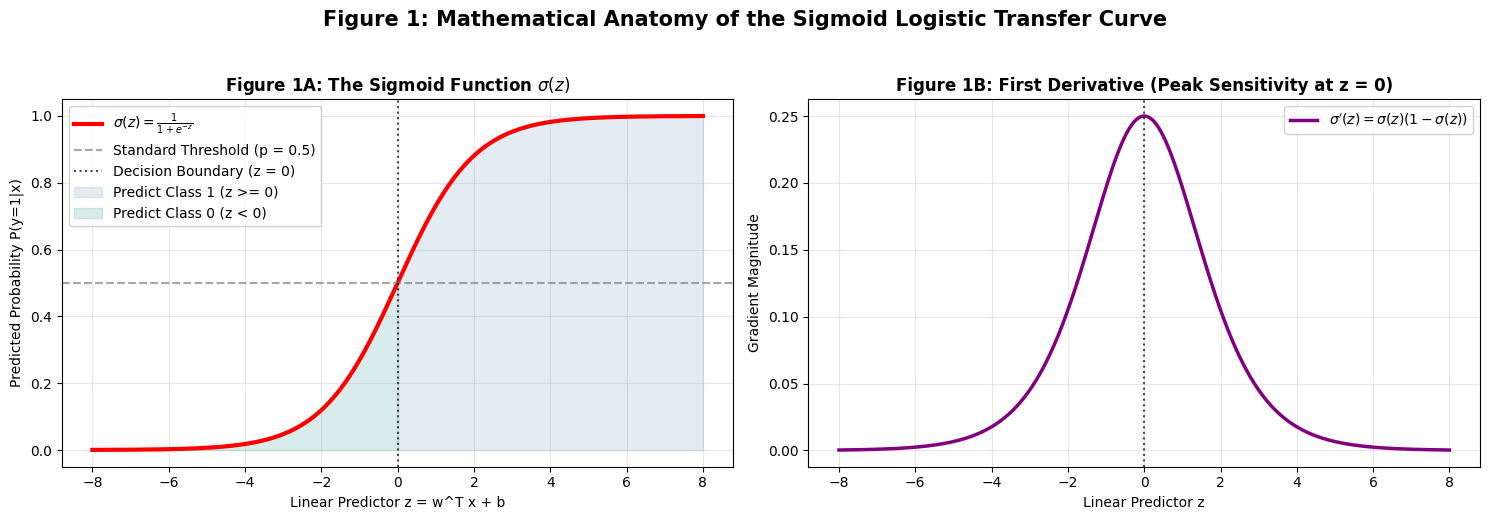

In [1]:
# PLOT 1: The Canonical Sigmoid Activation Function and Probability Interpretation
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-8, 8, 500)
sigma_z = 1 / (1 + np.exp(-z))
derivative = sigma_z * (1 - sigma_z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Sigmoid Curve
ax1.plot(z, sigma_z, color='red', linewidth=3, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Standard Threshold (p = 0.5)')
ax1.axvline(0, color='black', linestyle=':', alpha=0.7, label='Decision Boundary (z = 0)')
ax1.fill_between(z, sigma_z, where=(z >= 0), color='steelblue', alpha=0.15, label='Predict Class 1 (z >= 0)')
ax1.fill_between(z, sigma_z, where=(z < 0), color='teal', alpha=0.15, label='Predict Class 0 (z < 0)')
ax1.set_title("Figure 1A: The Sigmoid Function $\sigma(z)$", fontweight='bold')
ax1.set_xlabel("Linear Predictor z = w^T x + b")
ax1.set_ylabel("Predicted Probability P(y=1|x)")
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# First Derivative (Gradient)
ax2.plot(z, derivative, color='purple', linewidth=2.5, label=r"$\sigma'(z) = \sigma(z)(1 - \sigma(z))$")
ax2.axvline(0, color='black', linestyle=':', alpha=0.7)
ax2.set_title("Figure 1B: First Derivative (Peak Sensitivity at z = 0)", fontweight='bold')
ax2.set_xlabel("Linear Predictor z")
ax2.set_ylabel("Gradient Magnitude")
ax2.legend(loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Figure 1: Mathematical Anatomy of the Sigmoid Logistic Transfer Curve", y=1.03, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="3-import-libraries-data"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Task 3: Import Libraries & Ingest Wisconsin Breast Cancer Dataset</span>


In [2]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score, 
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA

# Configure plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

# Load Breast Cancer Wisconsin (Diagnostic) Dataset
cancer = load_breast_cancer()
df_cancer = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df_cancer['target'] = cancer.target  # 0: Malignant, 1: Benign
df_cancer['diagnosis'] = df_cancer['target'].map({0: 'Malignant', 1: 'Benign'})

print(f"Dataset Dimensions: {df_cancer.shape[0]} patient samples across {cancer.data.shape[1]} cellular features")
print(f"Target Distribution: {dict(df_cancer['diagnosis'].value_counts())}")
display(df_cancer.head(4).T.iloc[:10])

Dataset Dimensions: 569 patient samples across 30 cellular features
Target Distribution: {'Benign': np.int64(357), 'Malignant': np.int64(212)}


,0,1,2,3
mean radius,17.99,20.57,19.69,11.42
mean texture,10.38,17.77,21.25,20.38
mean perimeter,122.8,132.9,130.0,77.58
mean area,1001.0,1326.0,1203.0,386.1
mean smoothness,0.1184,0.08474,0.1096,0.1425
mean compactness,0.2776,0.07864,0.1599,0.2839
mean concavity,0.3001,0.0869,0.1974,0.2414
mean concave points,0.1471,0.07017,0.1279,0.1052
mean symmetry,0.2419,0.1812,0.2069,0.2597
mean fractal dimension,0.07871,0.05667,0.05999,0.09744


<a id="4-eda-target-balance"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Task 4: Exploratory Data Analysis (EDA) & Target Class Balance</span>


Total Missing Values in Dataset: 0


C:\Users\mohdf\AppData\Local\Temp\ipykernel_14124\4080370838.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cancer, x='diagnosis', palette={'Malignant': 'crimson', 'Benign': 'blue'}, ax=ax_bar, alpha=0.85)


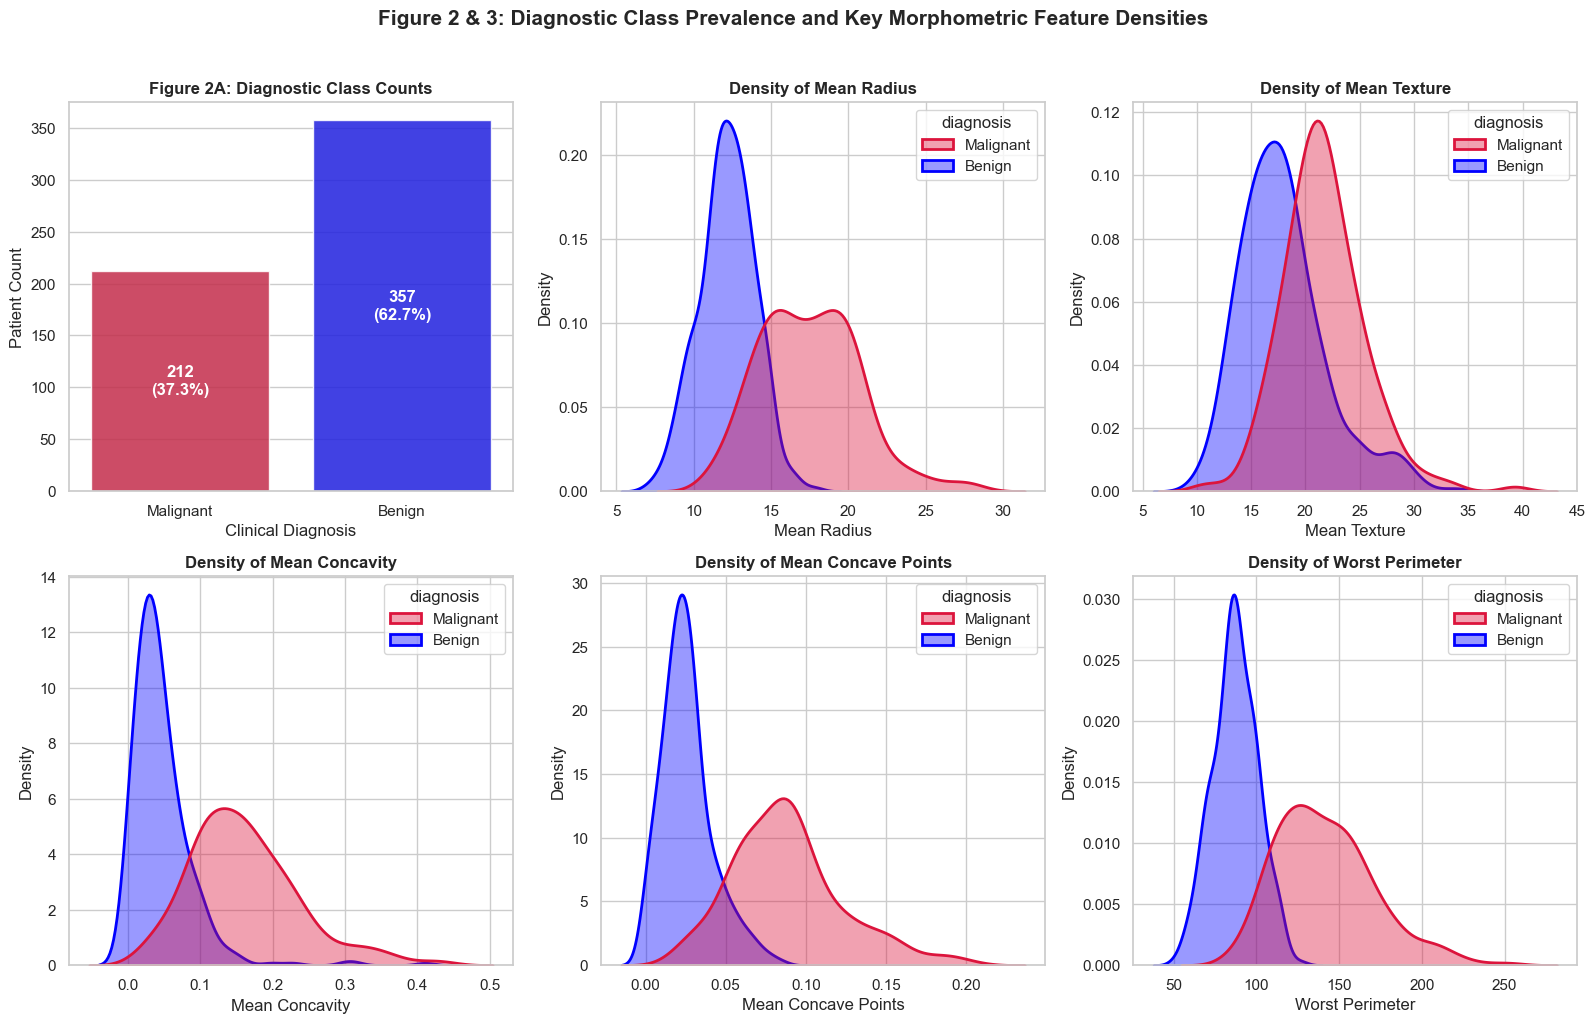

In [3]:
# Check missing values and general info
print("Total Missing Values in Dataset:", df_cancer.isnull().sum().sum())

# PLOT 2 & 3: Class Distribution and Feature Stratification
fig = plt.figure(figsize=(16, 10))

# Subplot 2A: Class Breakdown Pie & Count
ax_bar = plt.subplot2grid((2, 3), (0, 0))
sns.countplot(data=df_cancer, x='diagnosis', palette={'Malignant': 'crimson', 'Benign': 'blue'}, ax=ax_bar, alpha=0.85)
ax_bar.set_title("Figure 2A: Diagnostic Class Counts", fontweight='bold')
ax_bar.set_xlabel("Clinical Diagnosis")
ax_bar.set_ylabel("Patient Count")
for p in ax_bar.patches:
    ax_bar.annotate(f"{int(p.get_height())}\n({p.get_height()/len(df_cancer)*100:.1f}%)",
                    (p.get_x() + p.get_width() / 2., p.get_height() / 2.),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Subplots 3: Key Clinical Indicators Distributions Stratified by Diagnosis
key_features = ['mean radius', 'mean texture', 'mean concavity', 'mean concave points', 'worst perimeter']
colors = {'Malignant': 'crimson', 'Benign': 'blue'}

positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
for idx, feat in enumerate(key_features):
    ax = plt.subplot2grid((2, 3), positions[idx])
    sns.kdeplot(data=df_cancer, x=feat, hue='diagnosis', fill=True, common_norm=False,
                palette=colors, alpha=0.4, linewidth=2, ax=ax)
    ax.set_title(f"Density of {feat.title()}", fontweight='bold')
    ax.set_xlabel(feat.title())
    ax.set_ylabel("Density")

plt.suptitle("Figure 2 & 3: Diagnostic Class Prevalence and Key Morphometric Feature Densities", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="5-correlation-multicollinearity"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Task 5: Multicollinearity & Feature Correlation Analysis</span>


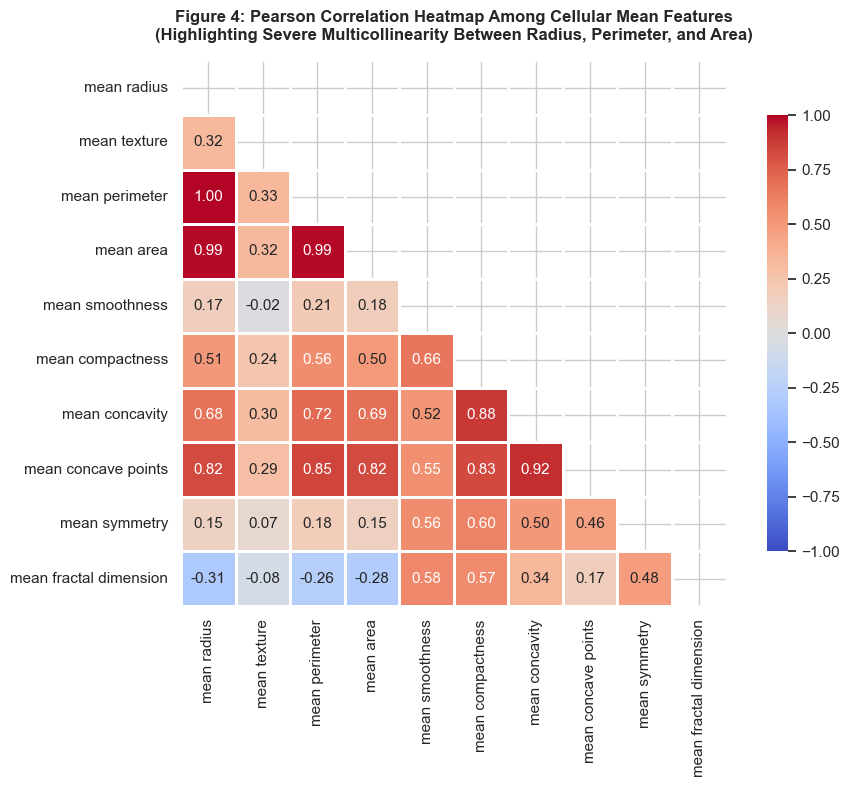

In [4]:
# PLOT 4: Correlation Matrix of 'Mean' Dimensional Features
mean_cols = [c for c in cancer.feature_names if 'mean' in c]

plt.figure(figsize=(10, 8))
corr_matrix = df_cancer[mean_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Figure 4: Pearson Correlation Heatmap Among Cellular Mean Features\n(Highlighting Severe Multicollinearity Between Radius, Perimeter, and Area)", pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="6-standardization-split"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Task 6: Feature Standardization & Stratified Train-Test Split</span>


**Beginner Note - Preventing Data Leakage in Logistic Regression:**
- Standardization scales each feature: $z = \frac{x - \mu}{\sigma}$.
- The parameters $\mu$ and $\sigma$ must be fitted **exclusively on the training partition**. If we fit on the full dataset before splitting, information from the test set leaks into the training pipeline!


In [5]:
# Separate feature matrix X and target vector y
X = df_cancer[cancer.feature_names].values
y = df_cancer['target'].values  # 1 = Benign, 0 = Malignant

# Stratified 80/20 train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training samples: {X_train.shape[0]} (Malignant: {np.sum(y_train == 0)}, Benign: {np.sum(y_train == 1)})")
print(f"Testing samples:  {X_test.shape[0]} (Malignant: {np.sum(y_test == 0)}, Benign: {np.sum(y_test == 1)})")

Training samples: 455 (Malignant: 170, Benign: 285)
Testing samples:  114 (Malignant: 42, Benign: 72)


<a id="7-baseline-logistic"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Task 7: Baseline Logistic Regression Model & Convergence Analysis</span>


In [6]:
# Fit baseline L2 Logistic Regression with default C=1.0 and lbfgs solver
log_reg_base = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
log_reg_base.fit(X_train, y_train)

y_pred_base = log_reg_base.predict(X_test)
y_prob_base = log_reg_base.predict_proba(X_test)[:, 1]

print(f"Solver Iterations to Convergence: {log_reg_base.n_iter_[0]}")
print(f"Baseline Test Accuracy: {log_reg_base.score(X_test, y_test) * 100:.2f}%\n")
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Malignant (0)', 'Benign (1)']))

Solver Iterations to Convergence: 19
Baseline Test Accuracy: 98.25%

Baseline Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


<a id="8-coefficients-odds-ratios"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Task 8: Model Interpretability — Feature Coefficients & Odds Ratios (Odds Ratios exp(Beta))</span>


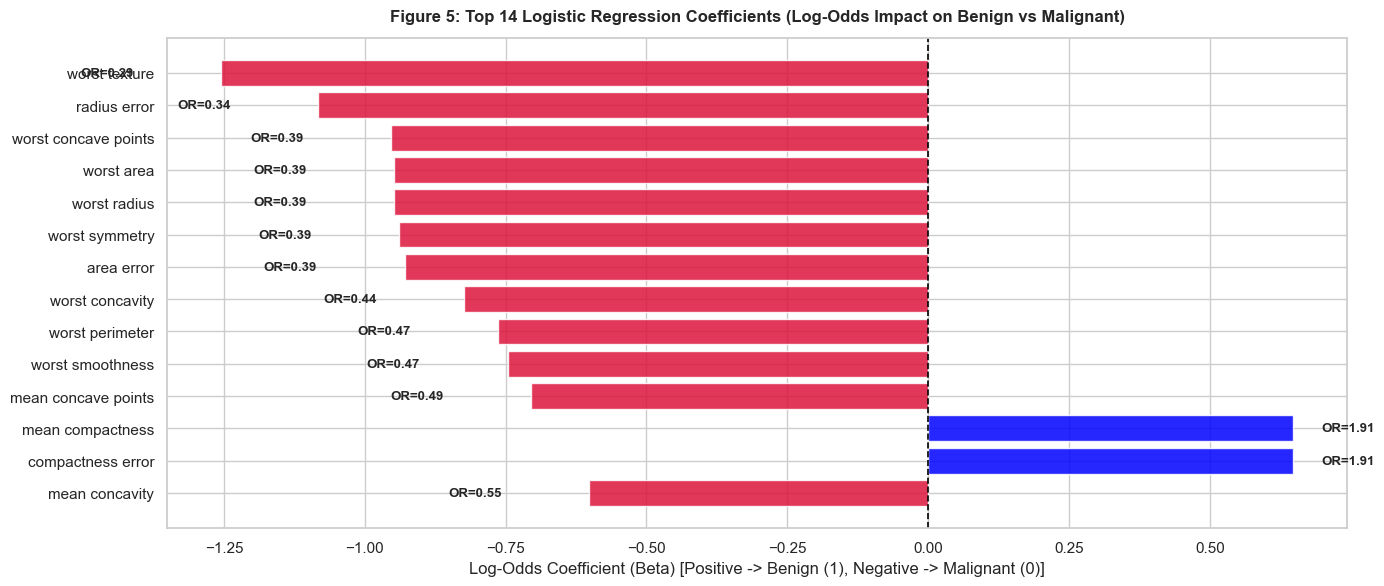

,Feature,Coefficient_beta,Odds_Ratio
21,worst texture,-1.255088,0.285051
10,radius error,-1.082965,0.338590
27,worst concave points,-0.953686,0.385318
23,worst area,-0.947756,0.387610
20,worst radius,-0.947616,0.387664
28,worst symmetry,-0.939181,0.390948


In [7]:
# PLOT 5: Feature Importance via Log-Odds Coefficients and Odds Ratios
coef_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Coefficient_beta': log_reg_base.coef_[0],
    'Odds_Ratio': np.exp(log_reg_base.coef_[0])
})

# Sort by absolute magnitude of coefficient
coef_df['Abs_Beta'] = coef_df['Coefficient_beta'].abs()
top_coefs = coef_df.sort_values(by='Abs_Beta', ascending=False).head(14)

plt.figure(figsize=(14, 6))
bar_colors = ['blue' if b > 0 else 'crimson' for b in top_coefs['Coefficient_beta']]

bars = plt.barh(top_coefs['Feature'][::-1], top_coefs['Coefficient_beta'][::-1], color=bar_colors[::-1], alpha=0.85)
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.title("Figure 5: Top 14 Logistic Regression Coefficients (Log-Odds Impact on Benign vs Malignant)", fontweight='bold', pad=12)
plt.xlabel("Log-Odds Coefficient (Beta) [Positive -> Benign (1), Negative -> Malignant (0)]")

# Annotate Odds Ratios
for bar, odds in zip(bars, top_coefs['Odds_Ratio'][::-1]):
    width = bar.get_width()
    offset = 0.05 if width >= 0 else -0.25
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f"OR={odds:.2f}",
             va='center', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.show()

display(top_coefs[['Feature', 'Coefficient_beta', 'Odds_Ratio']].head(6))

<a id="9-regularization-paths"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Task 9: Hyperparameter Optimization: Regularization Paths (L1 Lasso vs L2 Ridge)</span>


C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values:

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values:

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values:

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values:

...

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


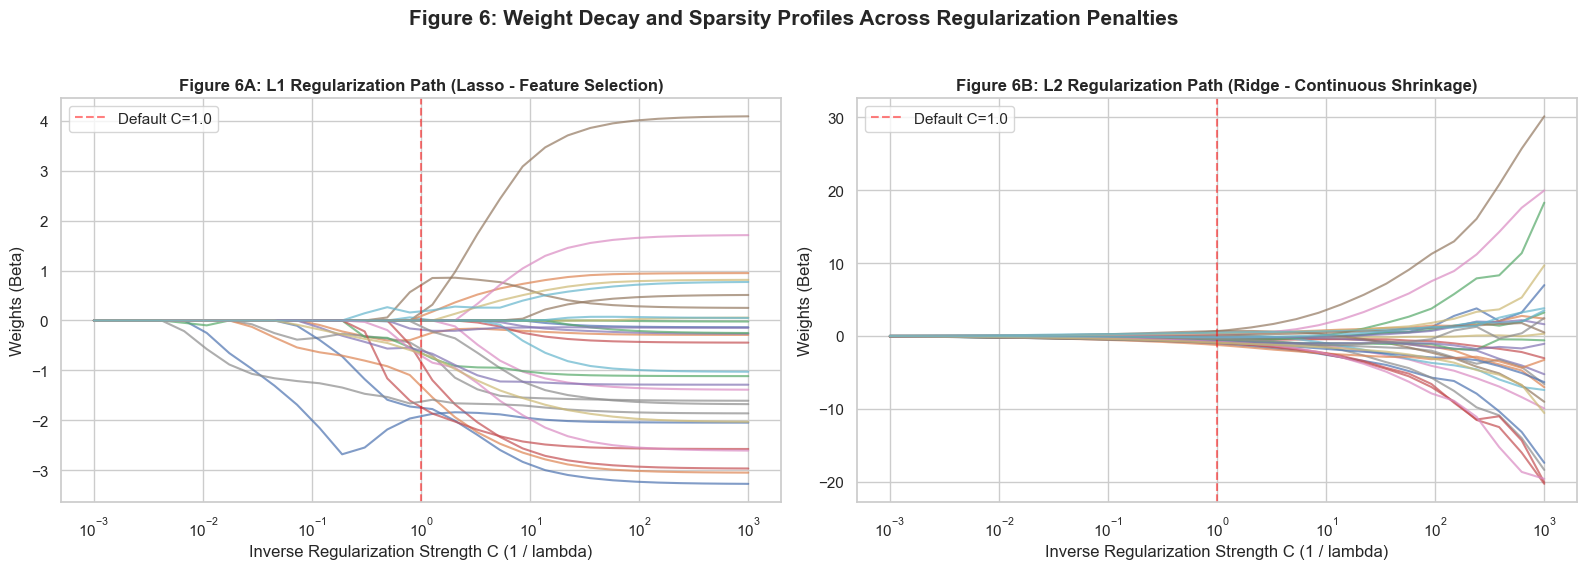

In [8]:
# PLOT 6: Regularization Paths across C values for L1 (Sparsity) and L2 (Shrinkage)
C_values = np.logspace(-3, 3, 30)
coefs_l1 = []
coefs_l2 = []

for c in C_values:
    # L1 Lasso (enforces sparsity)
    m_l1 = LogisticRegression(penalty='l1', C=c, solver='saga', max_iter=2000, random_state=42)
    m_l1.fit(X_train, y_train)
    coefs_l1.append(m_l1.coef_[0])
    
    # L2 Ridge (shrinks weights smoothly)
    m_l2 = LogisticRegression(penalty='l2', C=c, solver='lbfgs', max_iter=1000, random_state=42)
    m_l2.fit(X_train, y_train)
    coefs_l2.append(m_l2.coef_[0])

coefs_l1 = np.array(coefs_l1)
coefs_l2 = np.array(coefs_l2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

ax1.plot(C_values, coefs_l1, alpha=0.7)
ax1.set_xscale('log')
ax1.set_title("Figure 6A: L1 Regularization Path (Lasso - Feature Selection)", fontweight='bold')
ax1.set_xlabel("Inverse Regularization Strength C (1 / lambda)")
ax1.set_ylabel("Weights (Beta)")
ax1.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Default C=1.0')
ax1.legend(loc='upper left')

ax2.plot(C_values, coefs_l2, alpha=0.7)
ax2.set_xscale('log')
ax2.set_title("Figure 6B: L2 Regularization Path (Ridge - Continuous Shrinkage)", fontweight='bold')
ax2.set_xlabel("Inverse Regularization Strength C (1 / lambda)")
ax2.set_ylabel("Weights (Beta)")
ax2.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Default C=1.0')
ax2.legend(loc='upper left')

plt.suptitle("Figure 6: Weight Decay and Sparsity Profiles Across Regularization Penalties", y=1.03, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

In [9]:
# Grid Search for Best C and Penalty
param_grid = {
    'C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

grid_clf = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
grid_clf.fit(X_train, y_train)

best_log_reg = grid_clf.best_estimator_
print(f"Optimal Hyperparameters: {grid_clf.best_params_}")
print(f"Mean CV ROC-AUC: {grid_clf.best_score_:.4f}")

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


...

C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Optimal Hyperparameters: {'C': 0.5, 'penalty': 'l2', 'solver': 'saga'}
Mean CV ROC-AUC: 0.9957


C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


<a id="10-threshold-tuning"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">10. Task 10: Decision Threshold Optimization & Precision-Recall Trade-off</span>


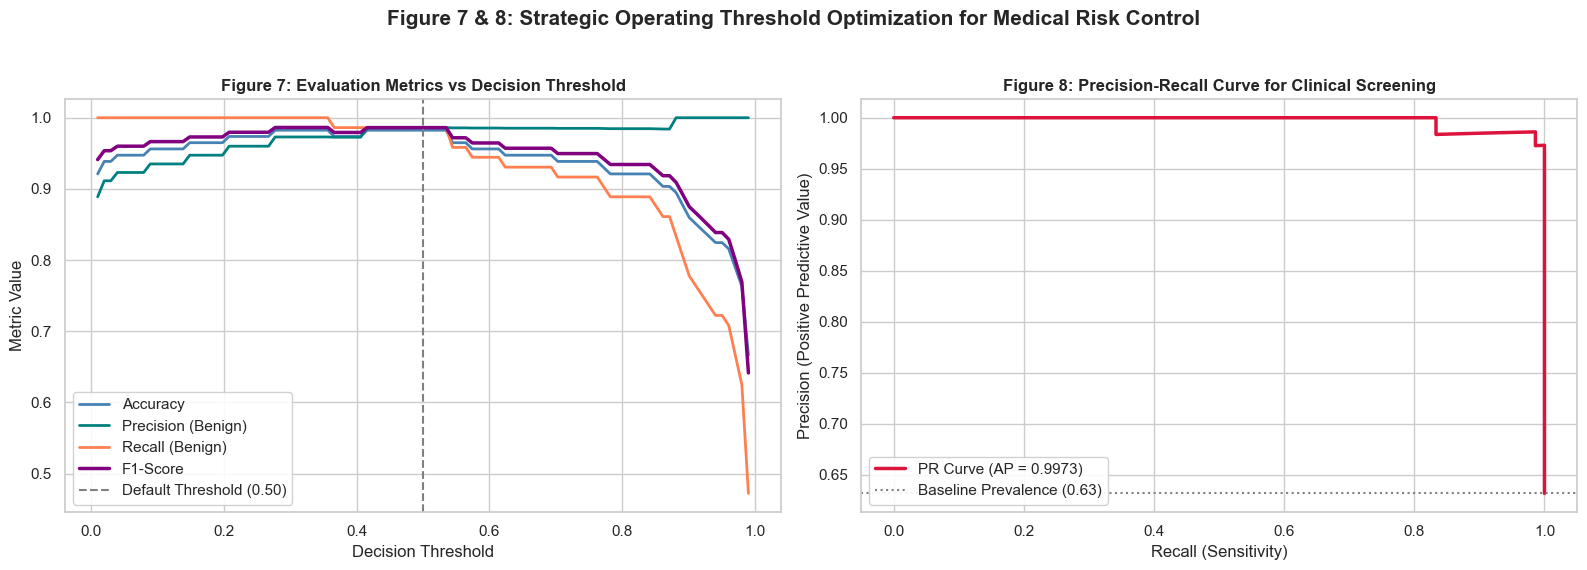

In [10]:
# PLOT 7 & 8: Metric Trajectories across Decision Thresholds and Precision-Recall Curve
y_test_probs = best_log_reg.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)
accuracies, precisions, recalls, f1s = [], [], [], []

for t in thresholds:
    y_t = (y_test_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_t).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    acc = (tp + tn) / len(y_test)
    
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# Subplot 7: Threshold Sweep
ax1.plot(thresholds, accuracies, label='Accuracy', color='steelblue', linewidth=2)
ax1.plot(thresholds, precisions, label='Precision (Benign)', color='teal', linewidth=2)
ax1.plot(thresholds, recalls, label='Recall (Benign)', color='coral', linewidth=2)
ax1.plot(thresholds, f1s, label='F1-Score', color='purple', linewidth=2.5)
ax1.axvline(0.5, color='gray', linestyle='--', label='Default Threshold (0.50)')
ax1.set_title("Figure 7: Evaluation Metrics vs Decision Threshold", fontweight='bold')
ax1.set_xlabel("Decision Threshold")
ax1.set_ylabel("Metric Value")
ax1.legend(loc='lower left', framealpha=0.9)

# Subplot 8: Precision-Recall Curve
prec_pts, rec_pts, _ = precision_recall_curve(y_test, y_test_probs)
ap_score = average_precision_score(y_test, y_test_probs)

ax2.plot(rec_pts, prec_pts, color='crimson', linewidth=2.5, label=f'PR Curve (AP = {ap_score:.4f})')
ax2.axhline(np.mean(y_test), color='gray', linestyle=':', label=f'Baseline Prevalence ({np.mean(y_test):.2f})')
ax2.set_title("Figure 8: Precision-Recall Curve for Clinical Screening", fontweight='bold')
ax2.set_xlabel("Recall (Sensitivity)")
ax2.set_ylabel("Precision (Positive Predictive Value)")
ax2.legend(loc='lower left', framealpha=0.9)

plt.suptitle("Figure 7 & 8: Strategic Operating Threshold Optimization for Medical Risk Control", y=1.03, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="11-pca-decision-boundary"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">11. Task 11: 2D Feature Space Decision Boundary via PCA</span>


C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


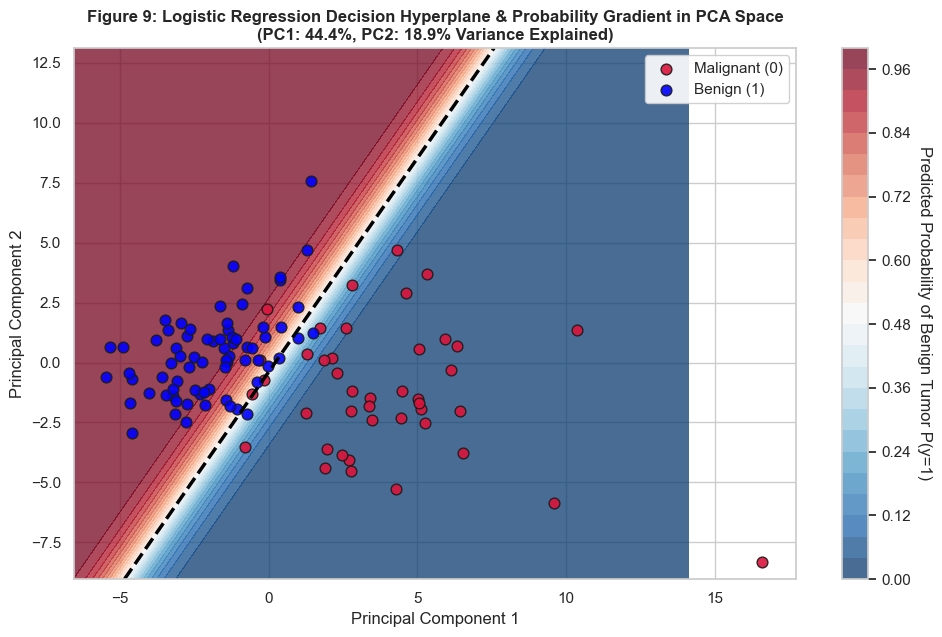

In [11]:
# PLOT 9: 2D Linear Decision Boundary and Probability Surface
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

clf_pca = LogisticRegression(C=best_log_reg.C, penalty=best_log_reg.penalty, solver='saga', random_state=42)
clf_pca.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = clf_pca.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6.5))
contour = plt.contourf(xx, yy, Z, 25, cmap='RdBu_r', alpha=0.75)
cbar = plt.colorbar(contour)
cbar.set_label("Predicted Probability of Benign Tumor P(y=1)", rotation=270, labelpad=15)

# Plot decision threshold boundary P = 0.5
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.5, linestyles='--')

# Scatter samples
colors = ['crimson', 'blue']
labels = ['Malignant (0)', 'Benign (1)']
for class_val, color, lbl in zip([0, 1], colors, labels):
    idx = (y_test == class_val)
    plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1], c=color, edgecolor='k', s=60, alpha=0.9, label=lbl)

var_ratio = pca.explained_variance_ratio_
plt.title(f"Figure 9: Logistic Regression Decision Hyperplane & Probability Gradient in PCA Space\n(PC1: {var_ratio[0]*100:.1f}%, PC2: {var_ratio[1]*100:.1f}% Variance Explained)", fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(framealpha=0.9, loc='upper right')
plt.tight_layout()
plt.show()

<a id="12-model-evaluation"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">12. Task 12: Comprehensive Final Model Evaluation (ROC-AUC, PR-AUC & Calibration)</span>


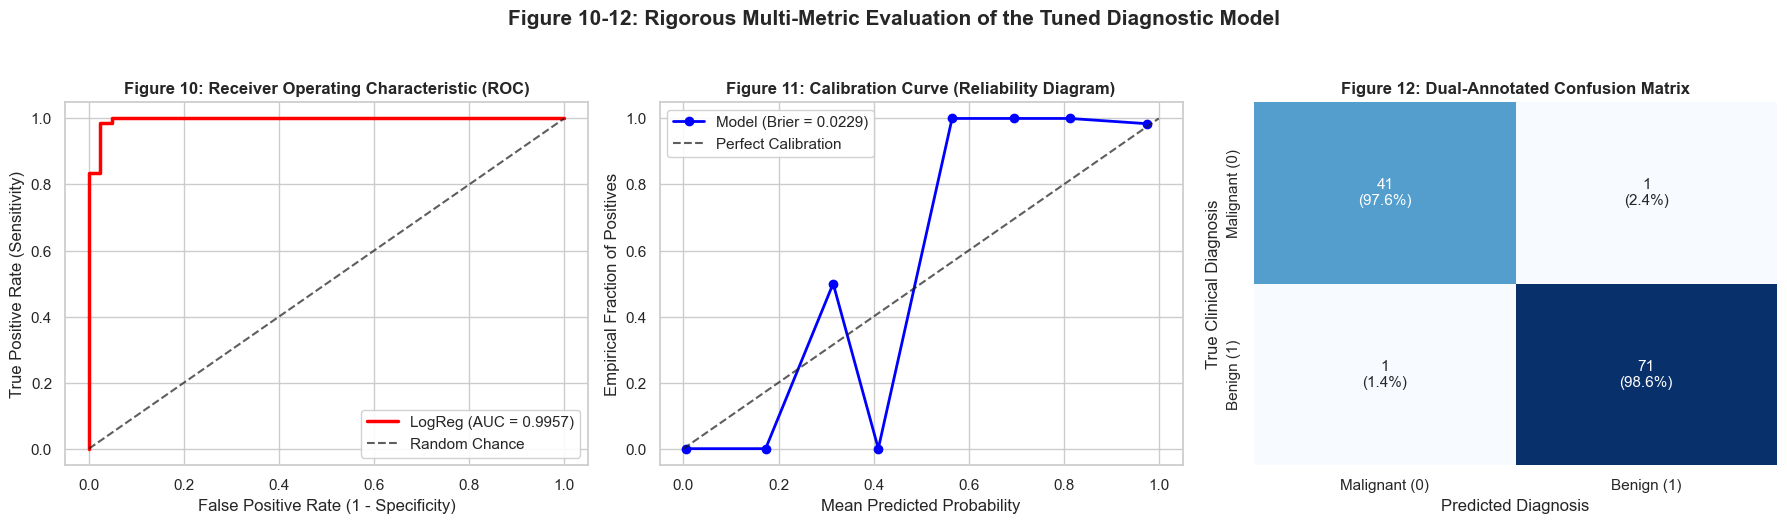

Final Tuned Model Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



In [12]:
# PLOT 10, 11 & 12: Final Evaluation Trinity (ROC Curve, Calibration Curve, Confusion Matrix)
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)
brier = brier_score_loss(y_test, y_test_probs)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: ROC Curve
ax1.plot(fpr, tpr, color='red', linewidth=2.5, label=f'LogReg (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Random Chance')
ax1.set_title("Figure 10: Receiver Operating Characteristic (ROC)", fontweight='bold')
ax1.set_xlabel("False Positive Rate (1 - Specificity)")
ax1.set_ylabel("True Positive Rate (Sensitivity)")
ax1.legend(loc='lower right', framealpha=0.9)

# Subplot 2: Reliability / Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_test_probs, n_bins=8, strategy='uniform')
ax2.plot(prob_pred, prob_true, marker='o', linewidth=2, color='blue', label=f'Model (Brier = {brier:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Perfect Calibration')
ax2.set_title("Figure 11: Calibration Curve (Reliability Diagram)", fontweight='bold')
ax2.set_xlabel("Mean Predicted Probability")
ax2.set_ylabel("Empirical Fraction of Positives")
ax2.legend(loc='upper left', framealpha=0.9)

# Subplot 3: Annotated Confusion Matrix
cm = confusion_matrix(y_test, best_log_reg.predict(X_test))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_cm = np.array([[f"{count}\n({norm*100:.1f}%)" for count, norm in zip(row_c, row_n)]
                     for row_c, row_n in zip(cm, cm_norm)])

sns.heatmap(cm, annot=annot_cm, fmt='', cmap='Blues', ax=ax3, cbar=False,
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
ax3.set_title("Figure 12: Dual-Annotated Confusion Matrix", fontweight='bold')
ax3.set_xlabel("Predicted Diagnosis")
ax3.set_ylabel("True Clinical Diagnosis")

plt.suptitle("Figure 10-12: Rigorous Multi-Metric Evaluation of the Tuned Diagnostic Model", y=1.04, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

print("Final Tuned Model Classification Report:")
print(classification_report(y_test, best_log_reg.predict(X_test), target_names=['Malignant (0)', 'Benign (1)']))

<a id="13-summary-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">13. Task 13: Clinical Insights & Practical Guidelines</span>


### 🩺 Clinical Decision Making & Modeling Takeaways

1. **Medical Consequence of Asymmetric Cost**:
   - In breast cancer screening, a **False Negative (predicting Benign when the tumor is Malignant)** can be fatal due to delayed treatment.
   - A **False Positive (predicting Malignant for Benign)** leads to follow-up biopsies and emotional stress, but is far less catastrophic.
   - Operating at a lower probability threshold (e.g. $p=0.30$) prioritizes **Recall / Sensitivity** for the Malignant class.

2. **Multicollinearity & Interpretability**:
   - Morphological features such as `mean radius`, `mean perimeter`, and `mean area` have Pearson correlation $>0.98$.
   - Under multicollinearity, standard linear regression coefficients become unstable with inflated standard errors.
   - $L_1$ Lasso or $L_2$ Ridge regularization stabilizes parameter estimates and prevents explosive variance.

3. **Probability Calibration**:
   - Logistic regression outputs well-calibrated probabilities natively because it optimizes Bernoulli Log-Loss (unlike Support Vector Machines or Naive Bayes which require Platt scaling or isotonic regression).
